## Clustering - KMeans, Agglomerative, Hierarchical + TSNE visualization 

In [13]:
import pandas as pd
df = pd.read_csv("../../data/samples_DBAASP/descriptors_positive_staphylococcus.csv")

In [14]:
# KMeans clustering

from sklearn import metrics
from sklearn.cluster import KMeans

silhouette_scores = []
for i in range(2, 100):
    kmeans = KMeans(n_clusters=i, random_state=0).fit(df)
    score = metrics.silhouette_score(df, kmeans.labels_, metric='euclidean')
    silhouette_scores.append(score)
    print(f"Silhouette score for {i} clusters: {score}")
avg = sum(silhouette_scores) / len(silhouette_scores)
print("Mean silhouette score:" + str(avg))


Silhouette score for 2 clusters: 0.35436842314687345
Silhouette score for 3 clusters: 0.2765021155193237
Silhouette score for 4 clusters: 0.19903881726813466
Silhouette score for 5 clusters: 0.1973412186532934
Silhouette score for 6 clusters: 0.20595764566163952
Silhouette score for 7 clusters: 0.19175492333519017
Silhouette score for 8 clusters: 0.194381626036041
Silhouette score for 9 clusters: 0.17049838532999187
Silhouette score for 10 clusters: 0.16970312534032878
Silhouette score for 11 clusters: 0.18394398306642876
Silhouette score for 12 clusters: 0.19287281001428563
Silhouette score for 13 clusters: 0.1923091276915913
Silhouette score for 14 clusters: 0.192935956881744
Silhouette score for 15 clusters: 0.1958692277017962
Silhouette score for 16 clusters: 0.18229483001180563
Silhouette score for 17 clusters: 0.18091021232792834
Silhouette score for 18 clusters: 0.17546914231804128
Silhouette score for 19 clusters: 0.17971253595802894
Silhouette score for 20 clusters: 0.17510526

In [15]:
# Agglomerative clustering

from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering

silhouette_scores = []
for i in range(2, 100):
    agg = AgglomerativeClustering(n_clusters=i).fit(df)
    score = metrics.silhouette_score(df, agg.labels_, metric='euclidean')
    silhouette_scores.append(score)
    print(f"Silhouette score for {i} clusters: {score}")
avg = sum(silhouette_scores) / len(silhouette_scores)
print("Mean silhouette score:" + str(avg))
    

Silhouette score for 2 clusters: 0.2746637349297011
Silhouette score for 3 clusters: 0.2776183511545875
Silhouette score for 4 clusters: 0.23283863819068915
Silhouette score for 5 clusters: 0.2007286820633598
Silhouette score for 6 clusters: 0.16786183191890064
Silhouette score for 7 clusters: 0.17110640487962836
Silhouette score for 8 clusters: 0.18097461852037858
Silhouette score for 9 clusters: 0.1780619799568099
Silhouette score for 10 clusters: 0.18402338431375953
Silhouette score for 11 clusters: 0.1626015690568448
Silhouette score for 12 clusters: 0.1675257019995204
Silhouette score for 13 clusters: 0.15925699016561443
Silhouette score for 14 clusters: 0.15609460862948762
Silhouette score for 15 clusters: 0.15625830765883256
Silhouette score for 16 clusters: 0.15722430896696346
Silhouette score for 17 clusters: 0.16057127466464877
Silhouette score for 18 clusters: 0.16015087891834714
Silhouette score for 19 clusters: 0.1611573589075483
Silhouette score for 20 clusters: 0.1642535

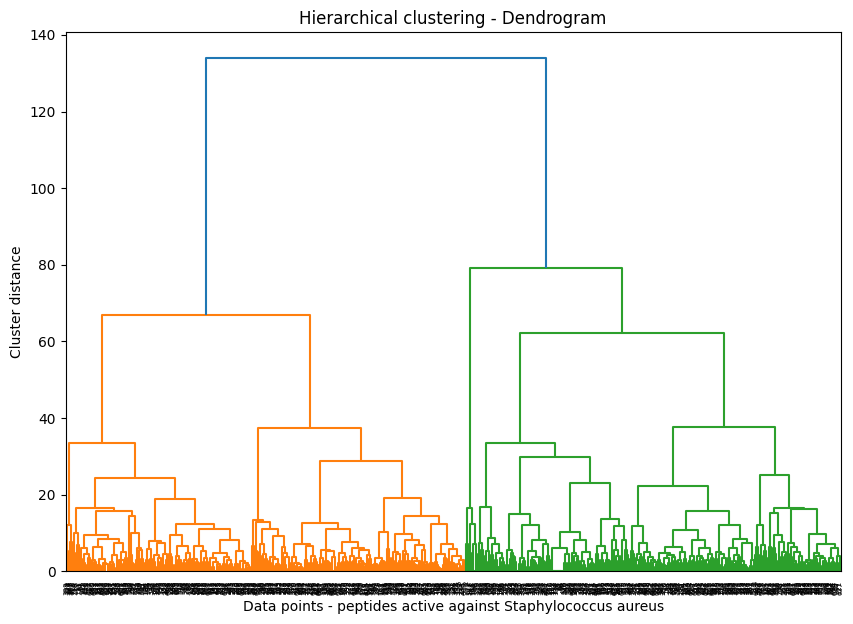

In [16]:
# dendrogram visualization - hierarchical clustering
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.title("Hierarchical clustering - Dendrogram")
dend = shc.dendrogram(shc.linkage(df, method='ward'))
plt.xlabel("Data points - peptides active against Staphylococcus aureus")
plt.ylabel("Cluster distance")
plt.savefig("Hierarchical clustering - dendrogram.png")
plt.show()

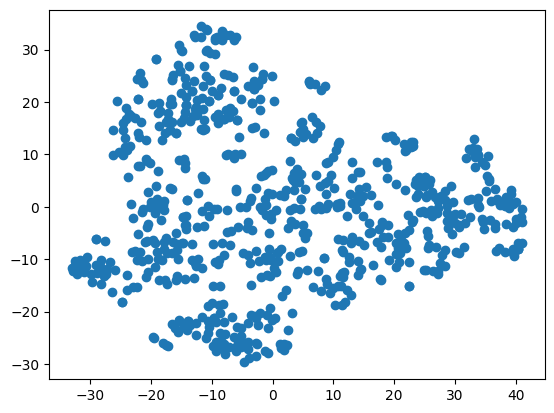

In [17]:
# TSNE visualization

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=0)
df_tsne = tsne.fit_transform(df)
plt.scatter(df_tsne[:, 0], df_tsne[:, 1])
plt.show()